# **Assessment 10: Dimensionality Reduction**

**Submitted by:**
* Benedict S. Caliba
* Marcelo B. Cosme
* Aaron Kane M. Dungca
  
**Date Submitted:** May 2, 2026

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import mean_squared_error

try:
    import umap
    UMAP_AVAILABLE = True
except ImportError:
    UMAP_AVAILABLE = False
    print("UMAP not available. Run: pip install umap-learn")
FEATURES = [
    'Birth Rate', 'Fertility Rate', 'Infant mortality',
    'Life expectancy', 'GDP', 'Unemployment rate',
    'Urban_population', 'Co2-Emissions',
    'Physicians per thousand', 'Density\n(P/Km2)']

# **Data Preparation**

## **Load Dataset**

In [2]:
# Load the dataset
df = pd.read_csv("world-data-2023.csv")
print(df.columns)

Index(['Country', 'Density\n(P/Km2)', 'Abbreviation', 'Agricultural Land( %)',
       'Land Area(Km2)', 'Armed Forces size', 'Birth Rate', 'Calling Code',
       'Capital/Major City', 'Co2-Emissions', 'CPI', 'CPI Change (%)',
       'Currency-Code', 'Fertility Rate', 'Forested Area (%)',
       'Gasoline Price', 'GDP', 'Gross primary education enrollment (%)',
       'Gross tertiary education enrollment (%)', 'Infant mortality',
       'Largest city', 'Life expectancy', 'Maternal mortality ratio',
       'Minimum wage', 'Official language', 'Out of pocket health expenditure',
       'Physicians per thousand', 'Population',
       'Population: Labor force participation (%)', 'Tax revenue (%)',
       'Total tax rate', 'Unemployment rate', 'Urban_population', 'Latitude',
       'Longitude'],
      dtype='str')


# **Feature Selection**

In [3]:
clean_df = df[FEATURES]
i_rows_num, i_cols_num = clean_df.shape

print(clean_df.head())
print(f"Rows: {i_rows_num}")
print(f"Columns: {i_cols_num}")

   Birth Rate  Fertility Rate  Infant mortality  Life expectancy  \
0       32.49            4.47              47.9             64.5   
1       11.78            1.62               7.8             78.5   
2       24.28            3.02              20.1             76.7   
3        7.20            1.27               2.7              NaN   
4       40.73            5.52              51.6             60.8   

                 GDP Unemployment rate Urban_population Co2-Emissions  \
0   $19,101,353,833             11.12%        9,797,273         8,672   
1   $15,278,077,447             12.33%        1,747,593         4,536   
2  $169,988,236,398             11.70%       31,510,100       150,006   
3    $3,154,057,987                NaN           67,873           469   
4   $94,635,415,870              6.89%       21,061,025        34,693   

   Physicians per thousand Density\n(P/Km2)  
0                     0.28               60  
1                     1.20              105  
2             

## **Data Cleaning**

In [4]:
# Display dataset non-null count and datatypes
clean_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 195 entries, 0 to 194
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Birth Rate               189 non-null    float64
 1   Fertility Rate           188 non-null    float64
 2   Infant mortality         189 non-null    float64
 3   Life expectancy          187 non-null    float64
 4   GDP                      193 non-null    str    
 5   Unemployment rate        176 non-null    str    
 6   Urban_population         190 non-null    str    
 7   Co2-Emissions            188 non-null    str    
 8   Physicians per thousand  188 non-null    float64
 9   Density
(P/Km2)          195 non-null    str    
dtypes: float64(5), str(5)
memory usage: 15.4 KB


In [5]:
# Strip currency formatting from all object columns
for col in clean_df.select_dtypes(include='object').columns:
    clean_df[col] = (
        clean_df[col]
        .str.replace('$', '', regex=False)
        .str.replace(',', '', regex=False)
        .str.replace('%', '', regex=False)
        .str.strip()
        .astype(float)
    )
print(clean_df.head())

   Birth Rate  Fertility Rate  Infant mortality  Life expectancy  \
0       32.49            4.47              47.9             64.5   
1       11.78            1.62               7.8             78.5   
2       24.28            3.02              20.1             76.7   
3        7.20            1.27               2.7              NaN   
4       40.73            5.52              51.6             60.8   

            GDP  Unemployment rate  Urban_population  Co2-Emissions  \
0  1.910135e+10              11.12         9797273.0         8672.0   
1  1.527808e+10              12.33         1747593.0         4536.0   
2  1.699882e+11              11.70        31510100.0       150006.0   
3  3.154058e+09                NaN           67873.0          469.0   
4  9.463542e+10               6.89        21061025.0        34693.0   

   Physicians per thousand  Density\n(P/Km2)  
0                     0.28              60.0  
1                     1.20             105.0  
2                     1

In [18]:
# Remove rows with NaN values
clean_df = clean_df.dropna()

# Extract the dataset shape again
rows_num, cols_num = clean_df.shape

# Display the dataframe shape again
print(f"Rows: {rows_num}, Rows Removed: {i_rows_num - rows_num}")
print(f"Columns: {cols_num}")

Rows: 175, Rows Removed: 20
Columns: 10


## **Scale features**

In [7]:
# Extract values
X = clean_df.values
y = clean_df['GDP'].values

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Check the mean and standard deviation of the scaled X
print("Checking the mean and standard deviation of the scaled dataset.")
print(f"Mean: {X_scaled[:, 0].mean():.4f}") # Must be 0
print(f"Standard Deviation: {X_scaled[:, 0].std():.4f}") # Must be 1

Checking the mean and standard deviation of the scaled dataset.
Mean: 0.0000
Standard Deviation: 1.0000


## **Exploratory Data Analysis**

In [8]:
print(clean_df.describe())

       Birth Rate  Fertility Rate  Infant mortality  Life expectancy  \
count  175.000000      175.000000        175.000000       175.000000   
mean    20.506171        2.715600         21.462857        72.286286   
std      9.984809        1.297193         19.741727         7.495350   
min      6.400000        0.980000          1.400000        52.800000   
25%     11.350000        1.700000          6.050000        66.800000   
50%     18.250000        2.260000         14.000000        73.600000   
75%     29.245000        3.645000         33.250000        77.600000   
max     46.080000        6.910000         84.500000        84.200000   

                GDP  Unemployment rate  Urban_population  Co2-Emissions  \
count  1.750000e+02         175.000000      1.750000e+02   1.750000e+02   
mean   5.260913e+11           6.855771      2.420098e+07   1.909804e+05   
std    2.276129e+12           5.077504      7.832250e+07   8.681057e+05   
min    4.290166e+08           0.090000      2.41450

### **Feature Distribution**

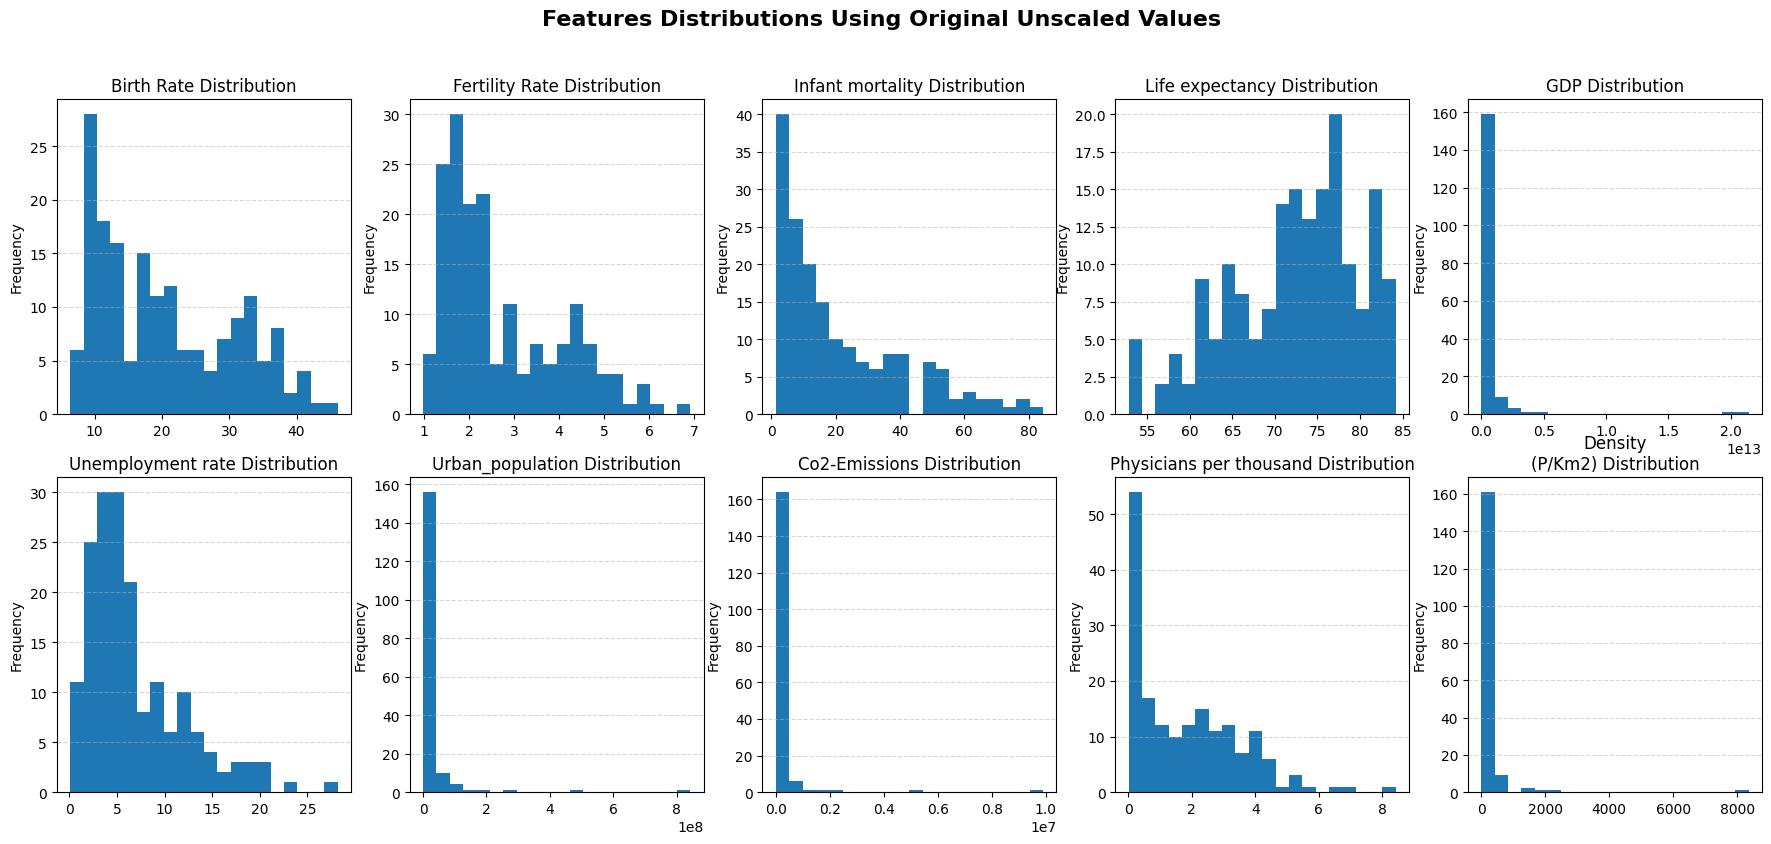

In [9]:
fig, axes = plt.subplots(2, 5, figsize=(22, 9))
fig.suptitle("Features Distributions Using Original Unscaled Values", fontsize=16, fontweight="bold")
axes = axes.flatten()

for idx, col in enumerate(clean_df.columns):
    axes[idx].hist(clean_df[col], bins=20, linewidth=0.6)
    axes[idx].set_title(f"{col} Distribution", fontsize=12)
    axes[idx].set_ylabel("Frequency")
    axes[idx].grid(axis="y", linestyle="--", alpha=0.5)

#### **Insights:**
- The features that are heavily skewed leaning to the right are `Urban_population`, `GDP`, `Density P(/Km2)`, `Co2-Emissions`
- In most of these distributions, they were changed / modified due to data cleaning.
- It is important to determine the skewed distributions before running PCA because PCA automically assumes variance which becomes not true for heavily skewed distributions
- Since the features haven't been standardized / scaled, the covariance matrix would dominate high-variance features regardless of importance

### **Correlation Heatmap**

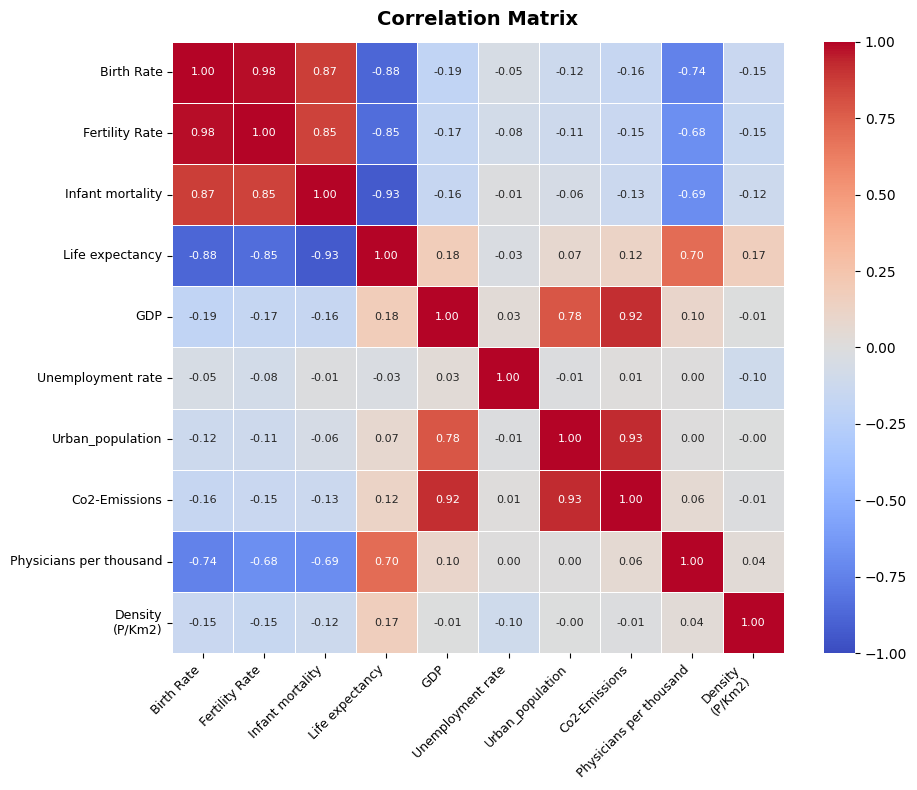

Top 8 Correlations by Magnitude
       Feature 1        Feature 2  Correlation
      Birth Rate   Fertility Rate         0.98
Infant mortality  Life expectancy        -0.93
Urban_population    Co2-Emissions         0.93
             GDP    Co2-Emissions         0.92
      Birth Rate  Life expectancy        -0.88
      Birth Rate Infant mortality         0.87
  Fertility Rate Infant mortality         0.85
  Fertility Rate  Life expectancy        -0.85


In [10]:
corr = clean_df.corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr,
    cmap='coolwarm',       # better than viridis for correlation — negative=blue, positive=red
    annot=True,
    fmt=".2f",             # rounds annotations to 2 decimal places
    square=True,
    linewidths=0.5,        # adds grid lines between cells
    linecolor='white',
    annot_kws={"size": 8}, # smaller font so numbers don't overlap
    vmin=-1, vmax=1,       # forces full correlation range
    center=0               # centers colormap at 0
)

plt.title('Correlation Matrix', fontsize=14, fontweight='bold', pad=12)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.show()

upper_tri = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

corr_pairs = upper_tri.stack().reset_index().round(2)
corr_pairs.columns = ['Feature 1', 'Feature 2', 'Correlation']

# Sort by absolute value, keep original sign
top_8 = corr_pairs.reindex(
    corr_pairs['Correlation'].abs().nlargest(8).index
)

print(f"Top 8 Correlations by Magnitude\n{'='*35}")
print(top_8.to_string(index=False))

#### **Insights:**

|Features|Correlation Score|
|---|---|
|Birth Rate-Fertility Rate|0.98|
|Infant Mortality-Life Expectancy|-0.93|
|Urban population-CO2 Emissions|0.93|
|GDP-CO2 Emissions|0.92|
|Birth Rate-Life Expectancy|-0.88|
|Birth Rate-Infant Mortality|0.87|
|Fertility Rate-Infant Mortality|0.85|
|Fertility Rate-Life Expectancy|-0.85|

* Based on the table, the strongest positive & negative correlations are all things to do with `Birth Rate`, `Fertility Rate`, `Infant mortality`, `Life expectancy`, things that are most related to healthcare, as well as `GDP`, `Urban_population` and `CO2 Emissions`, things that are about urbanization and environment.
* Usually, these features most commonly tell a sign of how developed a country's healthcare and living conditions are.
* For example, a country with low birth rate, low fertility rate is highly correlated with having a high life expectancy as well as low infant mortality rate.
* On the other hand, a country with a high GDP and overall number of urban population has a high correlation score with producing higher levels of CO2 emissions in comparison to countires that have lower GDP and urban populations.

# **Principal Component Analysis**

## **Fit PCA with all 10 components**

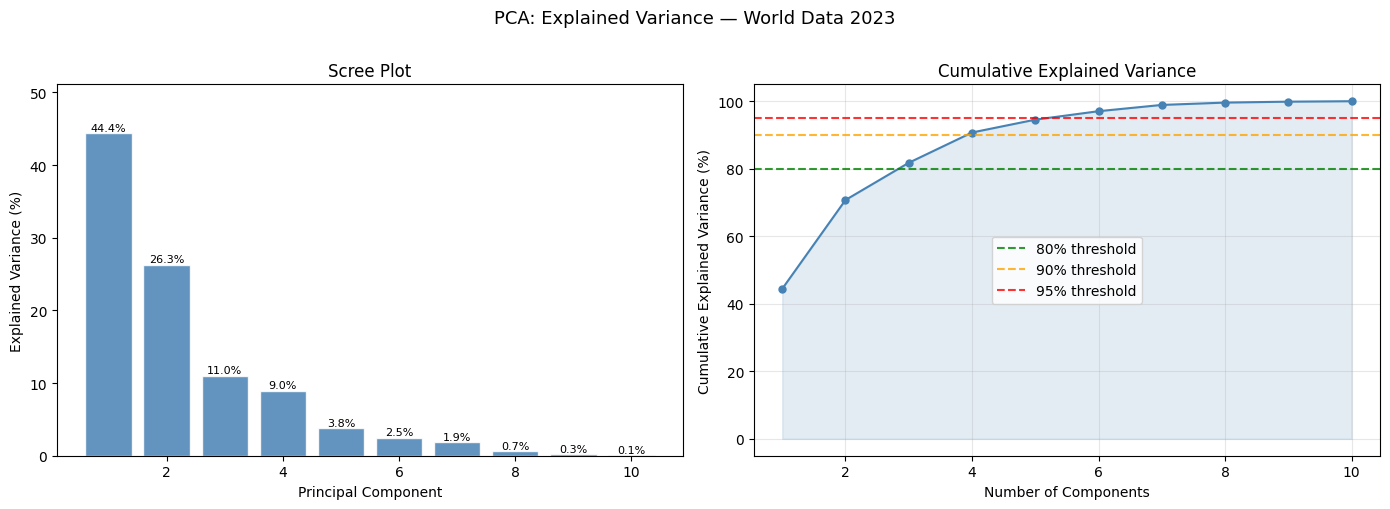

EXPLAINED VARIANCE BY COMPONENT
  Component     Explained   Cumulative
-------------------------------------------------------
  PC1              44.44%       44.44%
  PC2              26.30%       70.74%
  PC3              11.02%       81.76%
  PC4               8.97%       90.73%
  PC5               3.81%       94.54%
  PC6               2.50%       97.04%
  PC7               1.86%       98.90%
  PC8               0.69%       99.59%
  PC9               0.27%       99.86%
  PC10              0.14%      100.00%

  Components needed to explain 80% of variance: 3
  Components needed to explain 90% of variance: 4
  Components needed to explain 95% of variance: 6


In [11]:
# Fit PCA retaining all components first
pca_full = PCA(n_components=10, random_state=42)
pca_full.fit(X_scaled)

# --- Scree plot and cumulative explained variance ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scree plot
components = np.arange(1, len(pca_full.explained_variance_ratio_) + 1)
axes[0].bar(
    components, pca_full.explained_variance_ratio_ * 100,
    color='steelblue', edgecolor='white', alpha=0.85
)
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance (%)')
axes[0].set_title('Scree Plot')
for i, val in enumerate(pca_full.explained_variance_ratio_ * 100):
    axes[0].text(i + 1, val + 0.3, f'{val:.1f}%', ha='center', fontsize=8)
axes[0].set_ylim(0, max(pca_full.explained_variance_ratio_ * 100) * 1.15)

# Cumulative explained variance
cumvar = np.cumsum(pca_full.explained_variance_ratio_) * 100
axes[1].plot(components, cumvar, 'o-', color='steelblue', markersize=5)
axes[1].axhline(y=80, color='green',  linestyle='--', alpha=0.8, label='80% threshold')
axes[1].axhline(y=90, color='orange', linestyle='--', alpha=0.8, label='90% threshold')
axes[1].axhline(y=95, color='red',    linestyle='--', alpha=0.8, label='95% threshold')
axes[1].fill_between(components, cumvar, alpha=0.15, color='steelblue')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Explained Variance (%)')
axes[1].set_title('Cumulative Explained Variance')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('PCA: Explained Variance — World Data 2023', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

# --- Report ---
print("=" * 55)
print("EXPLAINED VARIANCE BY COMPONENT")
print("=" * 55)
print(f"  {'Component':<12} {'Explained':>10} {'Cumulative':>12}")
print("-" * 55)
cumulative = 0
for i, var in enumerate(pca_full.explained_variance_ratio_):
    cumulative += var
    print(f"  PC{i+1:<10} {var*100:>9.2f}% {cumulative*100:>11.2f}%")

n_80 = np.argmax(cumvar >= 80) + 1
n_90 = np.argmax(cumvar >= 90) + 1
n_95 = np.argmax(cumvar >= 95) + 1

print()
print(f"  Components needed to explain 80% of variance: {n_80}")
print(f"  Components needed to explain 90% of variance: {n_90}")
print(f"  Components needed to explain 95% of variance: {n_95}")

#### **Insights:**
- Based on the table, we require at least 3, 4, and 6 components to reach 80%, 90%, and 95% respectively.
- Going forward, we utilize as many as 4 components since it's able to explain 90.73% of the variance while still having dimensionality reduction from the 10 features.
- The main reason we chose PC4 is because beyond PC4, it's not able to explain the dimensions as effectively compared to all other components, all contributing to less than 4%.

## **Fit PCA with 2 components**

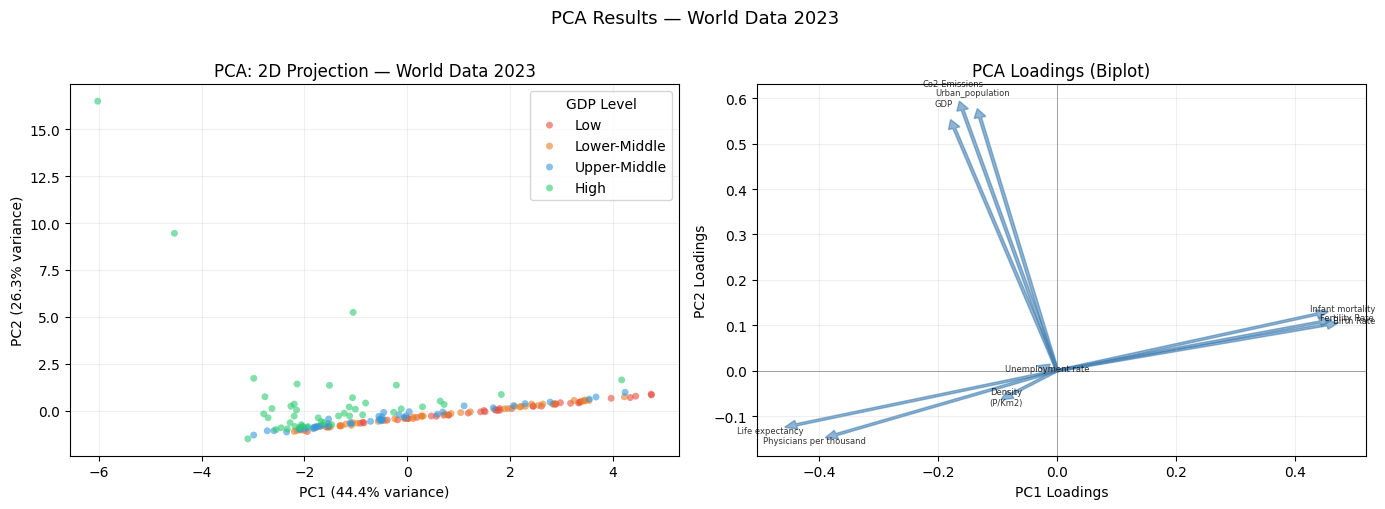

PCA 2D PROJECTION SUMMARY
  PC1 explains: 44.44% of variance
  PC2 explains: 26.30% of variance
  Combined:     70.74%

Top 5 features contributing most to PC1 (by absolute loading):
  +0.453  Birth Rate
  +0.442  Fertility Rate
  -0.439  Life expectancy
  +0.437  Infant mortality
  -0.371  Physicians per thousand


In [12]:
# Project onto first two PCs
pca_2d = PCA(n_components=2, random_state=42)
X_pca_2d = pca_2d.fit_transform(X_scaled)

# Project onto first ten PCs (for downstream use)
pca_10 = PCA(n_components=10, random_state=42)
X_pca_10 = pca_10.fit_transform(X_scaled)

# --- GDP Quartile Labels ---
quartile_labels = pd.qcut(clean_df['GDP'], q=4, labels=[0, 1, 2, 3])
y = quartile_labels.values.astype(int)

colors = {0: '#e74c3c', 1: '#e67e22', 2: '#3498db', 3: '#2ecc71'}
labels = {0: 'Low', 1: 'Lower-Middle', 2: 'Upper-Middle', 3: 'High'}

# 2D scatterplot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for cls in [0, 1, 2, 3]:
    mask = (y == cls)
    axes[0].scatter(
        X_pca_2d[mask, 0], X_pca_2d[mask, 1],
        c=colors[cls], label=labels[cls],
        alpha=0.6, s=25, edgecolors='none'
    )

axes[0].set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}% variance)')
axes[0].set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}% variance)')
axes[0].set_title('PCA: 2D Projection — World Data 2023')
axes[0].legend(title='GDP Level')
axes[0].grid(True, alpha=0.2)

# Loadings plot
feature_names = clean_df.columns.tolist()
loadings = pd.DataFrame(
    pca_2d.components_.T,
    index=feature_names,
    columns=['PC1', 'PC2']
)

for i, (feat, row) in enumerate(loadings.iterrows()):
    axes[1].arrow(0, 0, row['PC1'], row['PC2'],
                  head_width=0.02, head_length=0.02,
                  fc='steelblue', ec='steelblue', alpha=0.6, width=0.005)
    axes[1].text(row['PC1']*1.1, row['PC2']*1.1, feat,
                fontsize=6, ha='center', va='center', alpha=0.8)

axes[1].axhline(0, color='gray', linewidth=0.5)
axes[1].axvline(0, color='gray', linewidth=0.5)
axes[1].set_xlabel('PC1 Loadings')
axes[1].set_ylabel('PC2 Loadings')
axes[1].set_title('PCA Loadings (Biplot)')
axes[1].grid(True, alpha=0.2)

plt.suptitle('PCA Results — World Data 2023', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print("=" * 70)
print("PCA 2D PROJECTION SUMMARY")
print("=" * 70)
print(f"  PC1 explains: {pca_2d.explained_variance_ratio_[0]*100:.2f}% of variance")
print(f"  PC2 explains: {pca_2d.explained_variance_ratio_[1]*100:.2f}% of variance")
print(f"  Combined:     {sum(pca_2d.explained_variance_ratio_)*100:.2f}%")
print()
print("Top 5 features contributing most to PC1 (by absolute loading):")
top_pc1 = loadings['PC1'].abs().sort_values(ascending=False).head(5)
for feat, val in top_pc1.items():
    direction = "+" if loadings.loc[feat, 'PC1'] > 0 else "-"
    print(f"  {direction}{abs(val):.3f}  {feat}")

#### **Insights:**
1. **What does PC1 seem to represent based on which features load highest on it?**
- PC1 represents most the features `Birth Rate`, `Fertility Rate`, `Life Expectancy`, `Infant mortality`, and `Physicians per thousand`

2. **What does PC2 seem to capture that PC1 does not?**
- The features that PC2 seem to capture are `CO2 Emissions`, `Urban population`, and `GDP`
 
3. **Which development group clusters most tightly together? Which spreads out the most?**
- Based on the scatterplot, the development group that clusters the most would be `Low` and `Lower Middle` while the group that spreads out the most is `High`

## **Reconstruct PCA data and compute and plot MSE**

  k= 1: MSE = 0.5556
  k= 2: MSE = 0.2926
  k= 3: MSE = 0.1824
  k= 4: MSE = 0.0927
  k= 6: MSE = 0.0296
  k= 8: MSE = 0.0041
  k=10: MSE = 0.0000


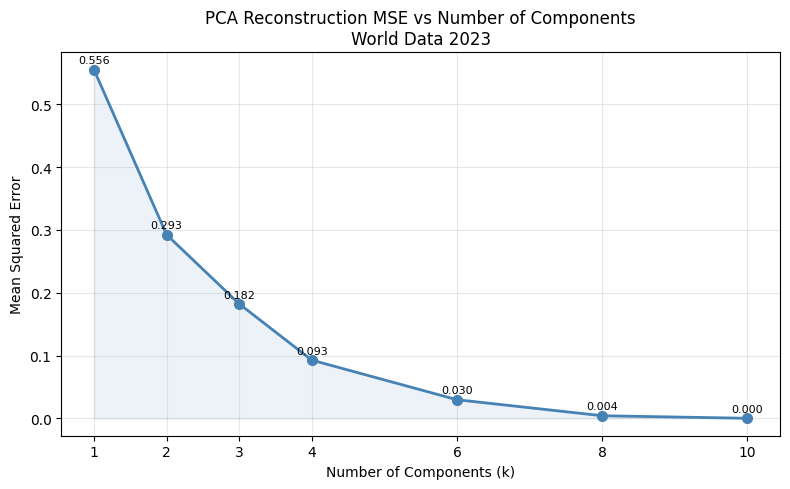


TOP 5 COUNTRIES — HIGHEST MSE (k=2)
      Country       MSE
    Singapore 13.996706
United States  2.125179
 South Africa  1.901195
      Lesotho  1.472875
        India  1.265305

TOP 5 COUNTRIES — LOWEST MSE (k=2)
           Country      MSE
          Slovakia 0.028150
        Luxembourg 0.024848
           Croatia 0.023651
Dominican Republic 0.020506
           Belgium 0.018254


In [13]:
k_values = [1, 2, 3, 4, 6, 8, 10]
mse_values = []

# --- Compute MSE for each k ---
for k in k_values:
    pca_k = PCA(n_components=k, random_state=42)
    X_reduced = pca_k.fit_transform(X_scaled)
    X_reconstructed = pca_k.inverse_transform(X_reduced)
    mse = mean_squared_error(X_scaled, X_reconstructed)
    mse_values.append(mse)
    print(f"  k={k:>2}: MSE = {mse:.4f}")

# --- Plot MSE vs Number of Components ---
plt.figure(figsize=(8, 5))
plt.plot(k_values, mse_values, 'o-', color='steelblue', linewidth=2, markersize=7)
plt.fill_between(k_values, mse_values, alpha=0.1, color='steelblue')
for x, y in zip(k_values, mse_values):
    plt.text(x, y + 0.01, f'{y:.3f}', ha='center', fontsize=8)
plt.xlabel('Number of Components (k)')
plt.ylabel('Mean Squared Error')
plt.title('PCA Reconstruction MSE vs Number of Components\nWorld Data 2023')
plt.xticks(k_values)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --- Per-country MSE at k=2 ---
pca_2 = PCA(n_components=2, random_state=42)
X_reduced_2 = pca_2.fit_transform(X_scaled)
X_reconstructed_2 = pca_2.inverse_transform(X_reduced_2)

# MSE per row (country)
per_country_mse = np.mean((X_scaled - X_reconstructed_2) ** 2, axis=1)

# Map numeric index -> country name from original df
country_names = df.loc[clean_df.index, 'Country'].values  # replace 'Country' with actual column name

country_mse_df = pd.DataFrame({
    'Country': country_names,
    'MSE': per_country_mse
}).sort_values('MSE', ascending=False).reset_index(drop=True)

print("\n" + "=" * 45)
print("TOP 5 COUNTRIES — HIGHEST MSE (k=2)")
print("=" * 45)
print(country_mse_df.head(5).to_string(index=False))

print("\n" + "=" * 45)
print("TOP 5 COUNTRIES — LOWEST MSE (k=2)")
print("=" * 45)
print(country_mse_df.tail(5).to_string(index=False))

#### **Insights:**
**Why do you think certain countries have high reconstruction error? What does that tell you about those countries?**
- A country with high MSE are likely outliers in the dataset, meaning their combination of dimensions and features are abnormal compared to other countries.
- Countries with high reconstruction error is a signifier that when PCA compressed the country's data to 2 components and rebuilt it, the rebuilt version was far from the original.
- 2 dimensions are not able to properly capture the country's dimensions or feature profiles, meaning that it is possible that the country doesn't follow the general "template" or pattern that PCA tries to predict.

# **t-SNE and UMAP**

t-SNE: EXPLORING PERPLEXITY SENSITIVITY

t-SNE key parameters:
  perplexity:   roughly the number of effective neighbors (~5-50)
  max_iter:     number of optimization steps (more = better convergence)
  random_state: always set for reproducibility

  Fitting t-SNE with perplexity=5... done
  Fitting t-SNE with perplexity=15... done
  Fitting t-SNE with perplexity=30... done
  Fitting t-SNE with perplexity=50... done


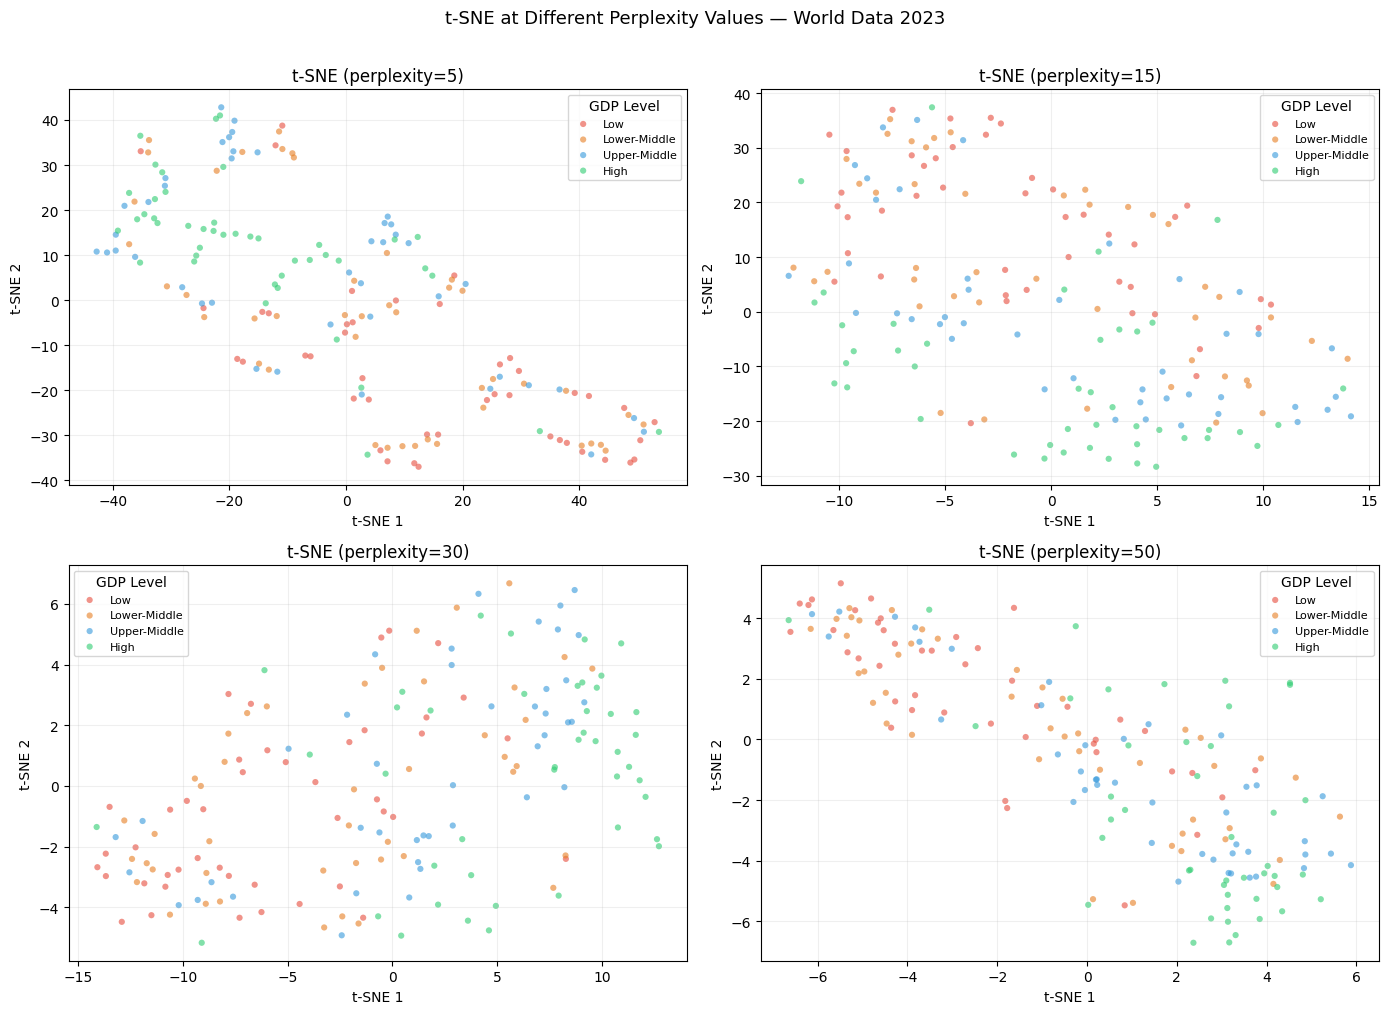


t-SNE PERPLEXITY SUMMARY TABLE
  Perplexity     Cluster Separation     Observation
----------------------------------------------------------------------
  5              Poor                   Fragmented micro-clusters; local structure dominates, groups scattered
  15             Fair                   Partial separation emerging; some GDP groups begin to cluster
  30             Good                   Cleaner separation across GDP levels; most representative view
  50             Excellent              Smooth, globally consistent clusters; high/low GDP well separated

CRITICAL REMINDERS about t-SNE:
  1. Distances between clusters are NOT interpretable.
  2. Cluster sizes are NOT meaningful.
  3. t-SNE is for VISUALIZATION ONLY — do not use as input features.
  4. Always run with multiple perplexity values before drawing conclusions.


In [14]:
# FIX Y GDP
quartile_labels = pd.qcut(clean_df['GDP'], q=4, labels=[0, 1, 2, 3])
y = quartile_labels.values.astype(int)

colors = {0: '#e74c3c', 1: '#e67e22', 2: '#3498db', 3: '#2ecc71'}
labels = {0: 'Low', 1: 'Lower-Middle', 2: 'Upper-Middle', 3: 'High'}

# print(type(y[0]))  # should say <class 'numpy.int64'> or similar
# print(np.unique(y))  # should say [0 1 2 3]

print("=" * 70)
print("t-SNE: EXPLORING PERPLEXITY SENSITIVITY")
print("=" * 70)
print()
print("t-SNE key parameters:")
print("  perplexity:   roughly the number of effective neighbors (~5-50)")
print("  max_iter:     number of optimization steps (more = better convergence)")
print("  random_state: always set for reproducibility")
print()

# Try four perplexity values
perplexities = [5, 15, 30, 50]
tsne_results = {}

for perp in perplexities:
    print(f"  Fitting t-SNE with perplexity={perp}...", end=" ")
    tsne = TSNE(n_components=2, perplexity=perp, max_iter=1000,
                random_state=42, learning_rate='auto', init='pca')
    tsne_results[perp] = tsne.fit_transform(X_scaled)
    print("done")

# --- 2x2 Grid Plot ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, perp in zip(axes, perplexities):
    Z = tsne_results[perp]
    for cls in [0, 1, 2, 3]:
        mask = (y == cls)
        ax.scatter(Z[mask, 0], Z[mask, 1],
                   c=colors[cls], label=labels[cls],
                   alpha=0.6, s=20, edgecolors='none')
    ax.set_title(f't-SNE (perplexity={perp})')
    ax.set_xlabel('t-SNE 1')
    ax.set_ylabel('t-SNE 2')
    ax.legend(title='GDP Level', fontsize=8)
    ax.grid(True, alpha=0.2)

plt.suptitle('t-SNE at Different Perplexity Values — World Data 2023',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

# --- Summary Table ---
print()
print("=" * 70)
print("t-SNE PERPLEXITY SUMMARY TABLE")
print("=" * 70)
print(f"  {'Perplexity':<14} {'Cluster Separation':<22} {'Observation'}")
print("-" * 70)
summary = [
    (5,  "Poor",      "Fragmented micro-clusters; local structure dominates, groups scattered"),
    (15, "Fair",      "Partial separation emerging; some GDP groups begin to cluster"),
    (30, "Good",      "Cleaner separation across GDP levels; most representative view"),
    (50, "Excellent", "Smooth, globally consistent clusters; high/low GDP well separated"),
]
for perp, quality, note in summary:
    print(f"  {perp:<14} {quality:<22} {note}")

print()
print("CRITICAL REMINDERS about t-SNE:")
print("  1. Distances between clusters are NOT interpretable.")
print("  2. Cluster sizes are NOT meaningful.")
print("  3. t-SNE is for VISUALIZATION ONLY — do not use as input features.")
print("  4. Always run with multiple perplexity values before drawing conclusions.")

#### **Insights:**

**Which perplexity gave the clearest result for this dataset? Why — what does perplexity actually control?**
- In my opinion, the best perplexity that showed the clearest results is ``perplexity=30``. Mainly since GDP levels are more cleanly separated compared to 50, and it's much more discernible when it comes to regions as opposed to 15.
    - ``perplexity=5`` is too fragmented. While yes it is spread apart and "separated", the regions aren't able to be formed since it's too sparse.
    - ``perplexity=15`` is where structure emerges but is still too sparse to form regions.
    - ``perplexity=30`` is the best balance between discernable regions and over-smoothing.
    - ``perplexity=50`` is over-smooth, visually the points and regions are too dense that it looks like a blob.
- Perplexity controls the number of effective neighbors each point considers. Low perplexity values places more importance on local structures (fragmented) while high perplexity values global structure (smoothness). 

UMAP: EXPLORING n_neighbors AND min_dist SENSITIVITY

Varying n_neighbors (min_dist=0.1 fixed):
  Fitting UMAP with n_neighbors=5... done
  Fitting UMAP with n_neighbors=15... done
  Fitting UMAP with n_neighbors=50... done

Varying min_dist (n_neighbors=15 fixed):
  Fitting UMAP with min_dist=0.0... done
  Fitting UMAP with min_dist=0.1... done
  Fitting UMAP with min_dist=0.5... done


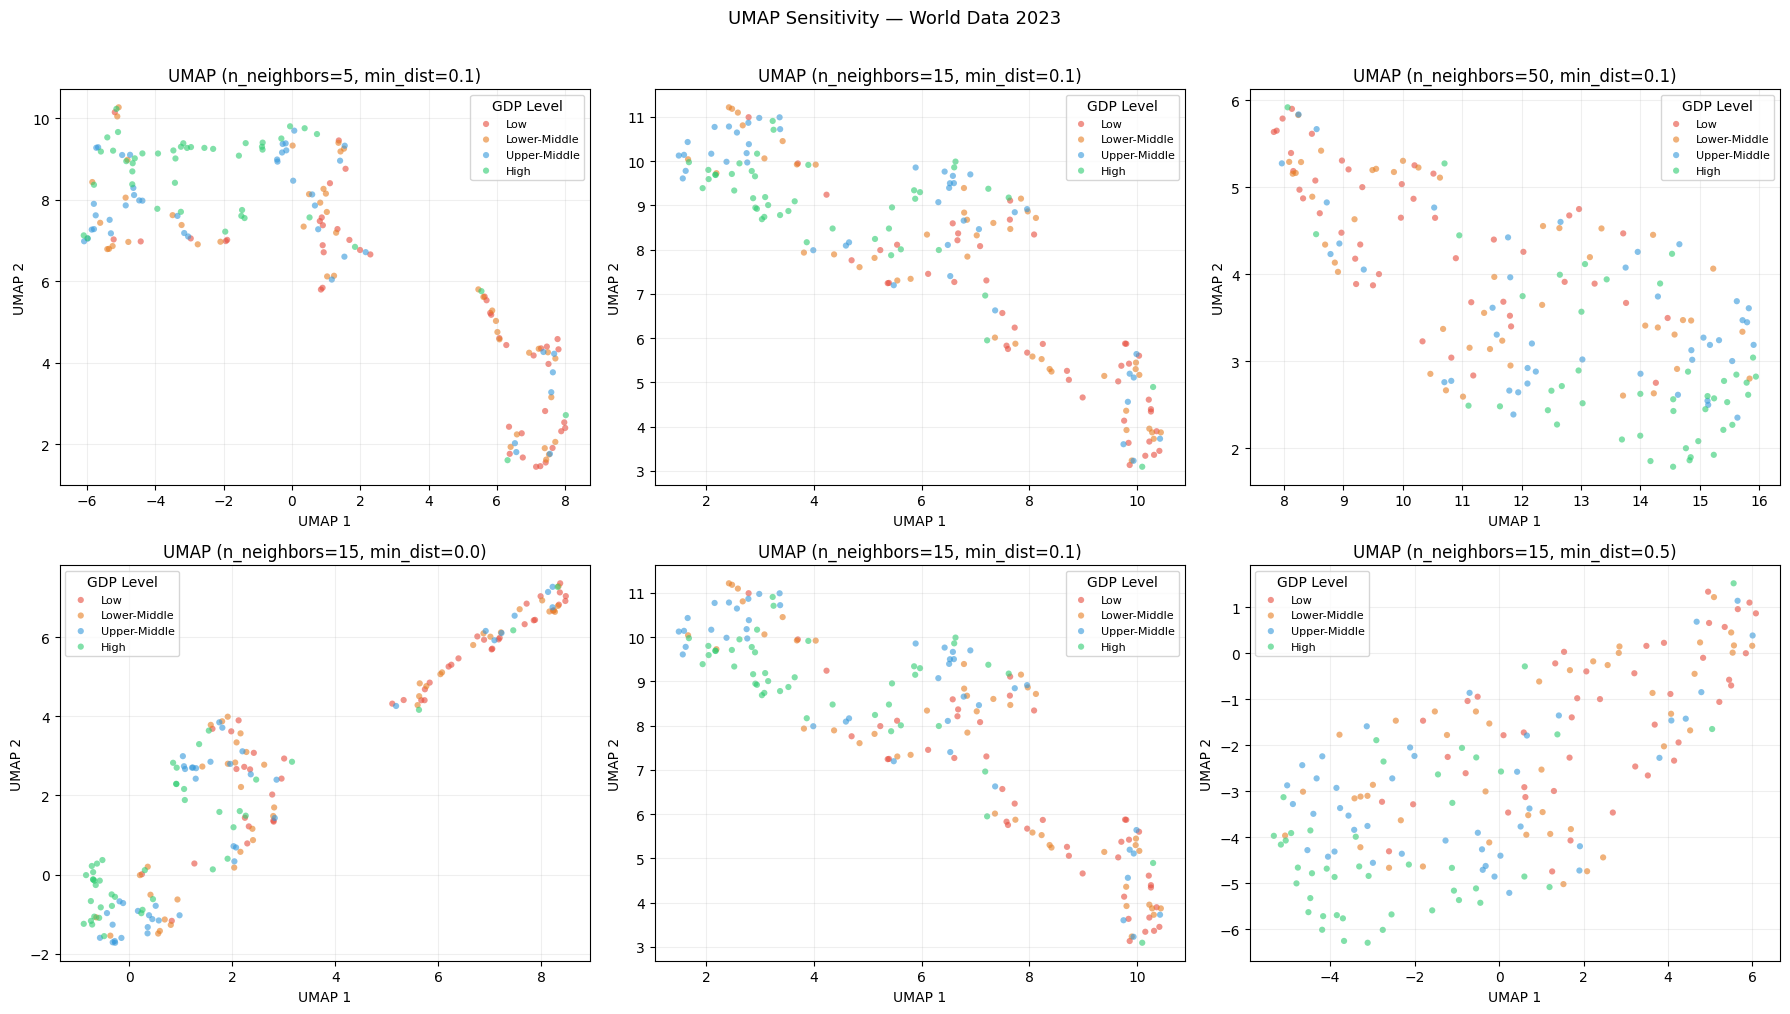

In [15]:
if UMAP_AVAILABLE:
    print("=" * 70)
    print("UMAP: EXPLORING n_neighbors AND min_dist SENSITIVITY")
    print("=" * 70)
    print()

    # Redefine y and colors to prevent overwrite issues
    quartile_labels = pd.qcut(clean_df['GDP'], q=4, labels=[0, 1, 2, 3])
    y = quartile_labels.values.astype(int)
    colors = {0: '#e74c3c', 1: '#e67e22', 2: '#3498db', 3: '#2ecc71'}
    gdp_labels = {0: 'Low', 1: 'Lower-Middle', 2: 'Upper-Middle', 3: 'High'}

    # --- Row 1: Varying n_neighbors, fixed min_dist=0.1 ---
    print("Varying n_neighbors (min_dist=0.1 fixed):")
    neighbor_values = [5, 15, 50]
    umap_results_n = {}
    for n in neighbor_values:
        print(f"  Fitting UMAP with n_neighbors={n}...", end=" ")
        reducer = umap.UMAP(n_components=2, n_neighbors=n,
                            min_dist=0.1, random_state=42)
        umap_results_n[n] = reducer.fit_transform(X_scaled)
        print("done")

    # --- Row 2: Varying min_dist, fixed n_neighbors=15 ---
    print("\nVarying min_dist (n_neighbors=15 fixed):")
    mindist_values = [0.0, 0.1, 0.5]
    umap_results_d = {}
    for d in mindist_values:
        print(f"  Fitting UMAP with min_dist={d}...", end=" ")
        reducer = umap.UMAP(n_components=2, n_neighbors=15,
                            min_dist=d, random_state=42)
        umap_results_d[d] = reducer.fit_transform(X_scaled)
        print("done")

    # --- 2x3 Grid Plot ---
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))

    # Row 1 — n_neighbors sensitivity
    for ax, n in zip(axes[0], neighbor_values):
        Z = umap_results_n[n]
        for cls in [0, 1, 2, 3]:
            mask = (y == cls)
            ax.scatter(Z[mask, 0], Z[mask, 1],
                       c=colors[cls], label=gdp_labels[cls],
                       alpha=0.6, s=20, edgecolors='none')
        ax.set_title(f'UMAP (n_neighbors={n}, min_dist=0.1)')
        ax.set_xlabel('UMAP 1')
        ax.set_ylabel('UMAP 2')
        ax.legend(title='GDP Level', fontsize=8)
        ax.grid(True, alpha=0.2)

    # Row 2 — min_dist sensitivity
    for ax, d in zip(axes[1], mindist_values):
        Z = umap_results_d[d]
        for cls in [0, 1, 2, 3]:
            mask = (y == cls)
            ax.scatter(Z[mask, 0], Z[mask, 1],
                       c=colors[cls], label=gdp_labels[cls],
                       alpha=0.6, s=20, edgecolors='none')
        ax.set_title(f'UMAP (n_neighbors=15, min_dist={d})')
        ax.set_xlabel('UMAP 1')
        ax.set_ylabel('UMAP 2')
        ax.legend(title='GDP Level', fontsize=8)
        ax.grid(True, alpha=0.2)

    plt.suptitle('UMAP Sensitivity — World Data 2023', fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()

else:
    print("UMAP not available. Install with: pip install umap-learn")
    print("Skipping UMAP section.")

#### **Insights:**

**What do n_neighbors and min_dist each control? How did changing them change your plots?**
- For `n_neighbors`, I observed changing it from 5 to 50 shows the local structure (fragmented) vs. global structure (smooth) clustering of the parameter, while for `min_dist` I saw the points go from incredibly dense to sparse and spread out.
- Having a low `n_neighbors` value makes the points more fragmented into small groups aka preserving local structure, while having a high value makes it global structure, wherein it becomes smoother and tries to preserve the bigger picture of the dataset.
- `min_dist` on the other hand controls how tight the points are packed within the graph. A low value makes them tightly clustered, while a high value is more spread out and sparse.

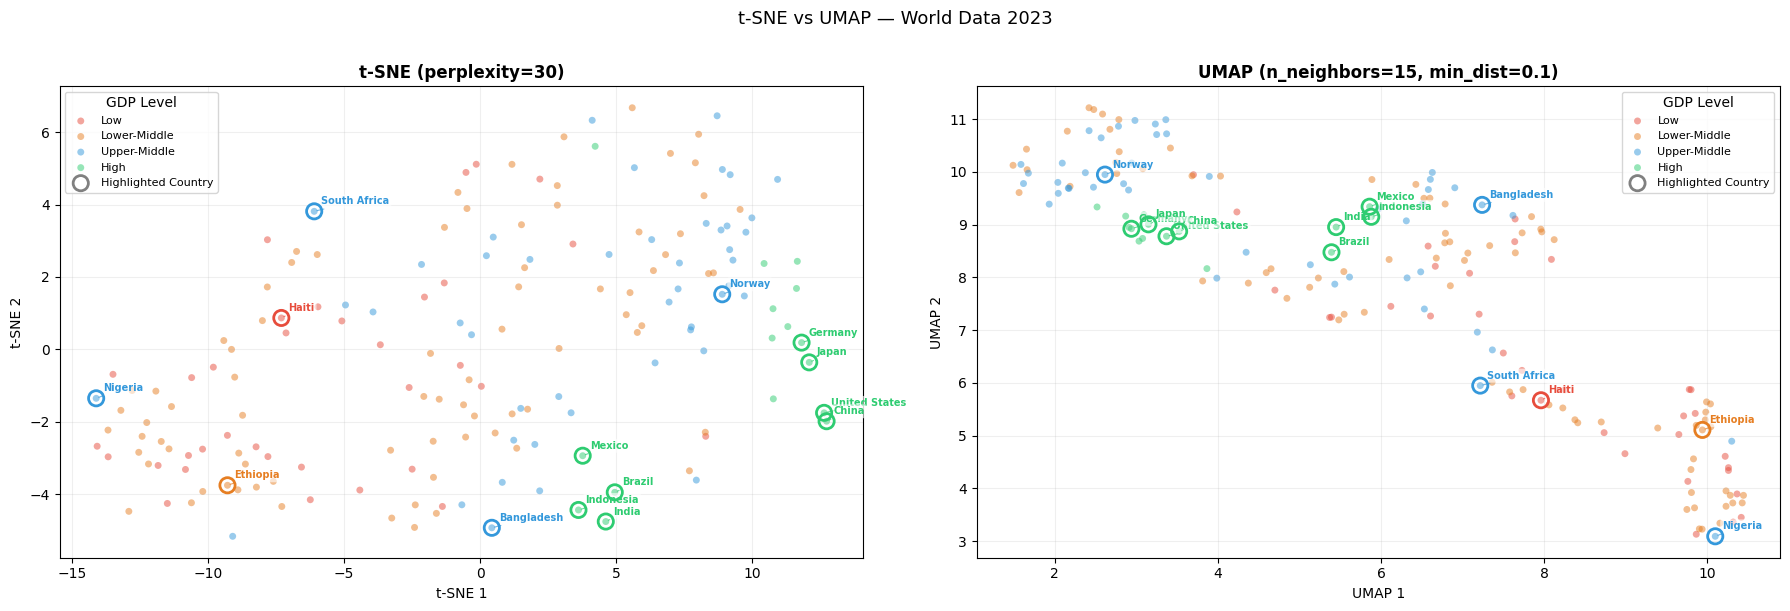

In [16]:
# Countries to label
target_countries = [
    "United States", "China", "India", "Brazil", "Germany",
    "Nigeria", "Ethiopia", "Japan", "Russian Federation", "South Africa",
    "Indonesia", "Mexico", "Bangladesh", "Norway", "Haiti"
]

# Redefine y and colors
bins = [0, 10e9, 100e9, 1e12, float('inf')]
quartile_labels = pd.cut(clean_df['GDP'], bins=bins, labels=[0, 1, 2, 3])
y = quartile_labels.values.astype(int)
colors = {0: '#e74c3c', 1: '#e67e22', 2: '#3498db', 3: '#2ecc71'}
gdp_labels = {0: 'Low', 1: 'Lower-Middle', 2: 'Upper-Middle', 3: 'High'}

# Country name mapping
country_names = df.loc[clean_df.index, 'Country'].values
country_to_pos = {name: pos for pos, name in enumerate(country_names)}

# Best results
Z_tsne = tsne_results[30]
Z_umap = umap_results_n[15]

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

for ax, Z, xlabel, ylabel, title in zip(
    axes,
    [Z_tsne, Z_umap],
    ['t-SNE 1', 'UMAP 1'],
    ['t-SNE 2', 'UMAP 2'],
    ['t-SNE (perplexity=30)', 'UMAP (n_neighbors=15, min_dist=0.1)']
):
    # Scatter all points by GDP level
    for cls in [0, 1, 2, 3]:
        mask = (y == cls)
        ax.scatter(Z[mask, 0], Z[mask, 1],
                   c=colors[cls], label=gdp_labels[cls],
                   alpha=0.5, s=25, edgecolors='none')

    # Highlight and label target countries
    for country in target_countries:
        if country in country_to_pos:
            idx = country_to_pos[country]
            cls = y[idx]
            point_color = colors[cls]
            # Highlight ring
            ax.scatter(Z[idx, 0], Z[idx, 1],
                       s=120, facecolors='none',
                       edgecolors=point_color, linewidths=2, zorder=5)
            # Label with bbox
            ax.annotate(
                country,
                xy=(Z[idx, 0], Z[idx, 1]),
                xytext=(5, 5), textcoords='offset points',
                fontsize=7, fontweight='bold', color=point_color,
                bbox=dict(boxstyle='round,pad=0.2',
                          facecolor='white', alpha=0.6, edgecolor='none'),
                arrowprops=dict(arrowstyle='-', color=point_color,
                                lw=0.8, alpha=0.7)
            )

    # Add highlighted country marker to legend
    ax.scatter([], [], facecolors='none', edgecolors='gray',
               linewidths=2, s=120, label='Highlighted Country')

    ax.set_title(title, fontweight='bold')
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.legend(title='GDP Level', fontsize=8)
    ax.grid(True, alpha=0.2)

plt.suptitle('t-SNE vs UMAP — World Data 2023', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

#### **Insights:**
- First world superpower countries such as United States, Germany, Japan, and China were grouped into High GDP level which is to be expected. All of them also clustered nearby one another as well, while less developed countries such as Haiti and Ethiopia were placed expectedly in their GDP level
- The countries that surprised me the most with their position was Norway being Upper-Middle GDP level while Indonesia was classified as High GDP level near Mexico. Bangladesh was also nearby India and Brazil, countries with economies that are rapidly developing.

# **Comparison and Recommendation**

## **PCA vs. t-SNE vs. UMAP**

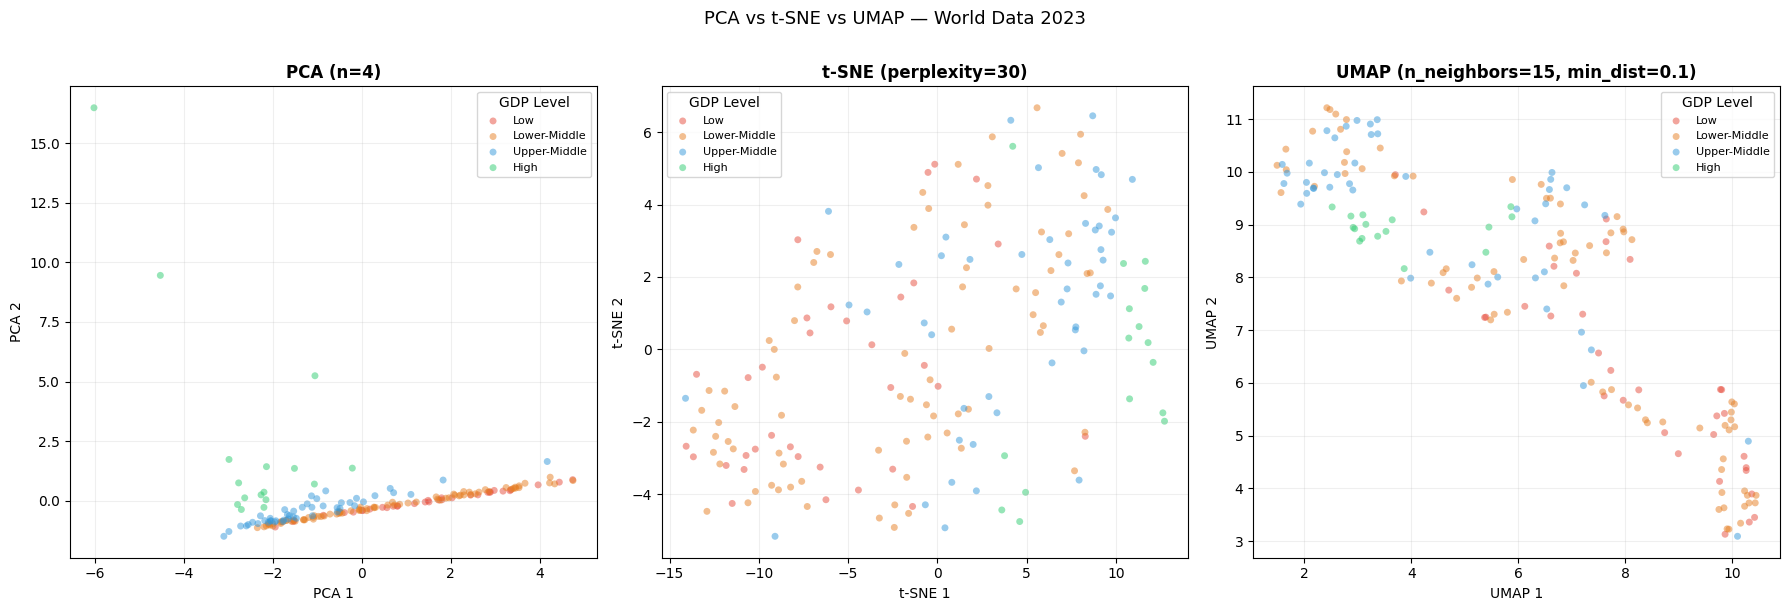

In [17]:
# Redefine y and colors
bins = [0, 10e9, 100e9, 1e12, float('inf')]
quartile_labels = pd.cut(clean_df['GDP'], bins=bins, labels=[0, 1, 2, 3])
y = quartile_labels.values.astype(int)
colors = {0: '#e74c3c', 1: '#e67e22', 2: '#3498db', 3: '#2ecc71'}
gdp_labels = {0: 'Low', 1: 'Lower-Middle', 2: 'Upper-Middle', 3: 'High'}

# Country name mapping
country_names = df.loc[clean_df.index, 'Country'].values
country_to_pos = {name: pos for pos, name in enumerate(country_names)}

# Best results
pca_4 = PCA(n_components=4, random_state=42)
X_pca_4 = pca_4.fit_transform(X_scaled)

# Select the first two components of PCA for the 2D scatter plot
Z_pca = X_pca_4[:, :2]
Z_tsne = tsne_results[30]
Z_umap = umap_results_n[15]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, Z, xlabel, ylabel, title in zip(
    axes,
    [Z_pca, Z_tsne, Z_umap],
    ['PCA 1', 't-SNE 1', 'UMAP 1'],
    ['PCA 2', 't-SNE 2', 'UMAP 2'],
    ['PCA (n=4)', 't-SNE (perplexity=30)', 'UMAP (n_neighbors=15, min_dist=0.1)']
):
    # Scatter all points by GDP level
    for cls in [0, 1, 2, 3]:
        mask = (y == cls)
        ax.scatter(Z[mask, 0], Z[mask, 1],
                   c=colors[cls], label=gdp_labels[cls],
                   alpha=0.5, s=25, edgecolors='none')

    ax.set_title(title, fontweight='bold')
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.legend(title='GDP Level', fontsize=8)
    ax.grid(True, alpha=0.2)

plt.suptitle('PCA vs t-SNE vs UMAP — World Data 2023', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## **Reflection:**

#### **Insights:**
**A team of policy analysts wants to group countries based on their development indicators to help design foreign aid programs. They need something they can explain to non-technical managers, understand which indicators drive the groupings, and apply to new countries next year.**
 
Write a recommendation for which method they should use. Your answer must cover all four points below. Use them as headers.

1. **What method do you recommend and why?**

* We recommend the PCA method since it is easily interpretable even by non-technical policy team and even civilians by just labelling the axes with the PC1 axis being the health axis of the countries and the PC2 axis being the economic and urban development of countries.
* Moreover, you can add new data or new countries for this instance by using PCA's transform() function.
* Unlike PCA, we did not pick UMAP and t-SNE because they have axes that are not interpretable, although UMAP is compatible with new data while t-SNE is incompatible.

2. **What from your results supports this? Point to at least two specific things you found in Parts 2 or 3.**

* According to our PCA 2D Projection Summary, both PC1 and PC2 explains 70.74% of variance which explains most of the variance.
* Moreover, it shows in the biplot arrow direction the features that are correlated (same direction) i.e. GDP and Urban Population, which means these features are usually high scoring if one of them is already a high score.
* This means we can monitor these features as a group and the features that are negatively correlated (opposite directions) i.e. Life Expectancy and Birth Rate.
* PCA also uses reconstruction or MSE which explains the countries that have an unusual combination of features i.e. high urbanization but low CO2.
* This helps us identify which countries are more confusing than the others which for this instance Singapore is the most confusing one, but since it rates how confusing a country is.
* It can also identify the countries that are the least confusing which for this dataset is the Slovakia.
* All of these will help policy analysts identify which countries require deeper individual investigation beyond what two components could capture.

3. **What are the limitations of your choice? Name at least two weaknesses and how the team should deal with them.**

* PCA only captures linear relationships, meaning it assumes that if GDP and Urban Population are correlated, they go up proportionally and consistently, but it could not be far from the truth.
* It may curve or plateau. An example is a country that is richer is not always proportionally healthier, so PCA might oversimplify the true relationship between features.
* Moreover, development is not linear. An example is Cuba with a low GDP but good health outcomes.
* There are countries that break the linear assumption, which PCA could misinterpret, to tackle the nonlinearity relationship problem.
* The policy team could use more components to capture more complexity, and for the countries that break the pattern, the policy team should use the MSE scores and both flag and review the high MSE countries individually.

4. **What are the other methods still good for? Even if you did not pick t-SNE or UMAP as the main method, explain where they still help.**
* t-SNE is still useful for showing local structures and clusters which is different from UMAP which shows the global structure better than t-SNE.
* Moreover, UMAP could still use the transform() function. You can use UMAP when the policy teams just want a quick look for the global structure of the dataset without caring about the axes.
* Similarly, if the policy team wants a quick look at a specific local structure and cluster, they could use t-SNE, since PCA captures most and is used as some kind of general recommendation.
* The policy team could use t-SNE and UMAP as visual validations to validate whether the groupings in PCA are consistent across different methods.